# State Space Methods for Time Series

State space models (SSMs) are the framework that quietly unifies most of classical time
series analysis. The idea is simple but powerful: the numbers we observe are treated as a
**noisy view of an unobserved "state"** that evolves over time. A *state equation* describes
how that hidden state moves from one step to the next, and an *observation equation* links
the state to the data we actually see. Almost everything else &mdash; random walks, ARIMA,
exponential smoothing, structural trend/seasonal models &mdash; turns out to be a special
case of this single template.

This notebook teaches the framework the way you'd want to learn it: by building up a **ladder
of models, each rung adding exactly one new component**, and by always attaching the theory to
the line of code that needs it. We will:

1. Implement the **Kalman filter from scratch** so the engine is not a black box.
2. Climb a structural ladder &mdash; **local level &rarr; local linear trend &rarr; seasonal** &mdash; using `statsmodels`' `UnobservedComponents`.
3. Show the **unification** explicitly: ARIMA (`SARIMAX`) and exponential smoothing (`ETSModel`) are *also* state space models.
4. Build a **custom model** with `MLEModel`, handle **missing data** by interpolation, and run a **head-to-head comparison**.

The implied reader is comfortable with Python but new to state space modeling. Every library
call is explained, and the statistical ideas arrive attached to the code that uses them.

# Setup

Every notebook in this style starts the same way: a single grouped imports cell, then one
configuration cell holding all the constants and plot styling. Getting this right once means
the rest of the notebook reads as short, declarative calls.

In [1]:
# Standard library imports
import warnings

# Third-party imports (data -> modeling -> visualization)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import adfuller

# Configuration & Settings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

Let's break the imports down. `import numpy as np` and `import pandas as pd` pull in the two
foundations of the scientific Python stack and bind them to the conventional short **aliases**
`np` and `pd`, so later code can write `np.array(...)` instead of the full module name. NumPy
gives us fast array and matrix math &mdash; essential, because a state space model *is*
a set of matrix recursions. Pandas gives us the `Series` and `DataFrame` objects we use to
carry a time series together with its date index. `matplotlib.pyplot as plt` is the plotting
library; every chart below goes through it.

The `statsmodels` imports are the heart of the notebook. `statsmodels.api as sm` is the
top-level entry point that exposes datasets and the high-level model classes. We then reach
deeper into the package for three specific tools: `MLEModel`, the base class we will subclass
to define a model from raw system matrices; `ETSModel`, the **state space** implementation of
exponential smoothing (distinct from the older `ExponentialSmoothing` &mdash; more on that
later); and `adfuller`, the Augmented Dickey-Fuller test we use to probe stationarity.

Finally, `warnings.simplefilter(...)` silences two categories of noisy-but-harmless warnings
that `statsmodels` emits during optimization, so the notebook output stays readable. We are
*not* suppressing errors &mdash; only cosmetic future-deprecation and convergence chatter.

In [2]:
# general settings
class CFG:
    SEED = 42
    HORIZON = 24          # months held out for forecast evaluation
    SEASONAL_PERIOD = 12  # monthly data -> yearly seasonality
    img_dim1 = 14
    img_dim2 = 6
    # consistent plot colors (used by every chart below)
    c_observed = "#1f3b73"   # observed series  : solid, dark blue
    c_fitted   = "#d62728"   # fitted / smoothed: red
    c_forecast = "#2ca02c"   # forecast         : green dashed
    c_ci       = "#ff9896"   # confidence band  : coral

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

The `CFG` class is a lightweight namespace that gathers every "magic number" and style choice
in one place &mdash; an idiom worth adopting in any analysis notebook. Storing constants as
class attributes (accessed as `CFG.HORIZON`, `CFG.SEED`, ...) keeps them out of the body cells,
so changing the holdout length or the seasonal period later means editing a single line here.

`SEED = 42` is the value we feed to NumPy's random number generator. Fixing the seed makes
every random draw in the notebook (simulated series, etc.) **reproducible**: rerun the notebook
and you get identical numbers and plots. `HORIZON = 24` is how many months we will hold out at
the end of each series to evaluate forecasts honestly, and `SEASONAL_PERIOD = 12` encodes that
monthly data repeats on a yearly cycle.

The three plotting lines establish conventions used consistently throughout: `plt.style.use(...)`
applies a clean theme, `plt.rcParams["figure.figsize"]` sets a wide default so time plots are
legible, and the color constants fix a visual grammar &mdash; **observed data in dark blue,
fitted/smoothed estimates in red, forecasts in dashed green, uncertainty bands in coral**. Once
learned, the same colors mean the same thing on every chart. The final `np.random.seed(CFG.SEED)`
actually applies the seed.

# Utils

Anything we do more than twice becomes a small helper here, parameterized with sensible
defaults, so the modeling cells stay short. We define five: a metrics function, a chronological
splitter, a stationarity-test printer, a forecast plotter that bakes in our color grammar, and
a comparison-table builder.

In [3]:
def forecast_metrics(actual, predicted):
    '''Return MAE / RMSE / MAPE as a rounded dict of plain floats.'''
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    err = actual - predicted
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mape = np.mean(np.abs(err / actual)) * 100
    return {"MAE": float(round(mae, 2)),
            "RMSE": float(round(rmse, 2)),
            "MAPE": float(round(mape, 2))}

`forecast_metrics` is our scorecard. It takes the true holdout values and the model's
predictions, coerces both to float NumPy arrays with `np.asarray` (so it works whether you pass
a list, a pandas `Series`, or an array), and computes three standard error measures from the
residual vector `err = actual - predicted`. **MAE** (mean absolute error) is the average size of
the miss in the original units; **RMSE** (root mean squared error) is similar but squares the
errors first, so it penalizes large misses more heavily; **MAPE** (mean absolute percentage
error) expresses the miss as a percentage of the actual value, which makes it comparable across
series of different scales. We round to two decimals and wrap each value in `float(...)` so the
returned dict prints cleanly and is JSON-friendly. Returning a dict (rather than printing) lets
us collect many models' scores into a table later.

In [4]:
def train_valid_split(series, horizon=CFG.HORIZON):
    '''Chronological split: everything but the last `horizon` points is training.'''
    train = series.iloc[:-horizon]
    valid = series.iloc[-horizon:]
    return train, valid

`train_valid_split` carves the series into a training portion and a validation portion. The
crucial detail is that the split is **chronological**, not random: `series.iloc[:-horizon]`
takes everything up to the last `horizon` observations as training, and `series.iloc[-horizon:]`
keeps that final stretch as the holdout. We never shuffle. Forecasting is about predicting the
*unseen future* from the *known past*, so the only honest test is to train on early data and
score on the latest data &mdash; a random split would leak future information into training and
flatter the model. The default `horizon=CFG.HORIZON` pulls from our config, so all models are
evaluated over the same window.

In [5]:
def print_adf_result(series, name="series"):
    '''Run an Augmented Dickey-Fuller test and print a readable verdict.'''
    clean = series.dropna()                  # the ADF test cannot handle NaNs
    stat, pvalue, _, _, crit, _ = adfuller(clean)
    print(f"ADF test on {name}")
    print(f"  test statistic : {stat:.3f}")
    print(f"  p-value        : {pvalue:.4f}")
    print(f"  critical (5%)  : {crit['5%']:.3f}")
    verdict = "stationary" if pvalue < 0.05 else "NON-stationary (likely a unit root)"
    print(f"  verdict        : {verdict}")

`print_adf_result` is a pretty-printer around the Augmented Dickey-Fuller (ADF) test, the
standard check for **stationarity** &mdash; whether a series' statistical properties (mean,
variance) stay constant over time. The first line, `series.dropna()`, is important: the ADF
test raises an error on missing values, so we strip any `NaN`s before testing. `adfuller`
returns a tuple; we unpack the test statistic, the p-value, and the dictionary of critical
values (ignoring the others with `_`). The test's null hypothesis is "the series has a unit
root" (i.e. it is non-stationary, like a random walk). A **small p-value (< 0.05) lets us reject
that null and call the series stationary**; a large p-value means we cannot, which is the
signature of a trending or random-walk series. This matters for state space modeling because
the framework handles non-stationarity *natively* &mdash; via stochastic trends and diffuse
initialization &mdash; rather than forcing us to difference the data first.

In [6]:
def plot_forecast(train, valid, fc_mean, lower=None, upper=None, title="", fitted=None):
    '''Standard forecast chart: observed + optional fitted + forecast + CI.'''
    fig, ax = plt.subplots()
    ax.plot(train.index, train.values, color=CFG.c_observed, lw=2, label="Observed (train)")
    ax.plot(valid.index, valid.values, color=CFG.c_observed, lw=2, ls=":", label="Observed (holdout)")
    if fitted is not None:
        ax.plot(fitted.index, fitted.values, color=CFG.c_fitted, lw=1.5, label="Fitted")
    ax.plot(fc_mean.index, fc_mean.values, color=CFG.c_forecast, lw=2, ls="--",
            marker="o", ms=3, label="Forecast")
    if lower is not None and upper is not None:
        ax.fill_between(fc_mean.index, lower, upper, color=CFG.c_ci, alpha=0.4, label="95% CI")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend()
    return ax

`plot_forecast` is the overlay chart we will reuse for every model, so the reader can *diff
methods rather than code*. It draws the observed training data as a solid dark-blue line and the
held-out actuals as a dotted continuation of the same color (so you can see how well the forecast
lands on the truth). An optional `fitted` series is drawn in red, the forecast mean in dashed
green with circular markers, and &mdash; if lower/upper bounds are supplied &mdash; a coral
confidence band via `fill_between`. Every styling choice comes from the `CFG` color constants,
so the visual grammar is identical across the notebook. We `return ax` rather than calling
`plt.show()` so a caller can tweak the axis afterward if needed.

In [7]:
def compare_models(scores, baseline):
    '''Turn a {name: rmse} dict into a tidy table with delta-vs-baseline and an improved flag.'''
    base_rmse = scores[baseline]
    rows = []
    for name, rmse in scores.items():
        rows.append({
            "model": name,
            "RMSE": rmse,
            "delta_vs_baseline": round(rmse - base_rmse, 2),
            "improved": bool(rmse < base_rmse),
        })
    df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return df

`compare_models` is the bookkeeping helper for the final showdown. Given a dictionary mapping
each model's name to its holdout RMSE and the name of a chosen `baseline`, it builds a tidy
`DataFrame` with one row per model: the RMSE itself, the **delta** against the baseline (negative
means lower error, i.e. better), and a boolean `improved` flag that is `True` when the model
beats the baseline. Sorting by RMSE puts the best model on top. This is the standard "tidy
comparison table with a delta column and an improved boolean" pattern &mdash; it makes the
relative performance of a family of models legible at a glance.

# Groundwork: the data and the engine

Before any modeling we establish two things: a real dataset to look at, and a working
understanding of the **Kalman filter**, the recursive algorithm that powers every state space
model. We will load the classic Nile River series, take a first look with a plot and a
stationarity test, and then implement the filter from scratch on controlled simulated data so the
machinery is transparent.

In [8]:
# Load the Nile River annual flow volume at Aswan, 1871-1970 (ships with statsmodels)
nile = sm.datasets.nile.load_pandas().data
nile.index = pd.period_range("1871", "1970", freq="Y").to_timestamp()
nile_y = nile["volume"]
nile.head(3)

,year,volume
1871-01-01,1871.0,1120.0
1872-01-01,1872.0,1160.0
1873-01-01,1873.0,963.0


We load the **Nile dataset**, a famous series of annual flow volumes of the Nile at Aswan from
1871 to 1970 that Durbin and Koopman use as their canonical example. `sm.datasets.nile.load_pandas().data`
returns a `DataFrame` with `year` and `volume` columns. The raw `year` column is just a float, so
we replace the index with a proper yearly `DatetimeIndex` built by `pd.period_range(...).to_timestamp()`
&mdash; giving the series a real time axis that plots and models can use. We extract the `volume`
column into `nile_y` for convenience, and end the cell with the bare expression `nile.head(3)` so
Jupyter displays the first three rows as a sanity check that the load and re-indexing worked.

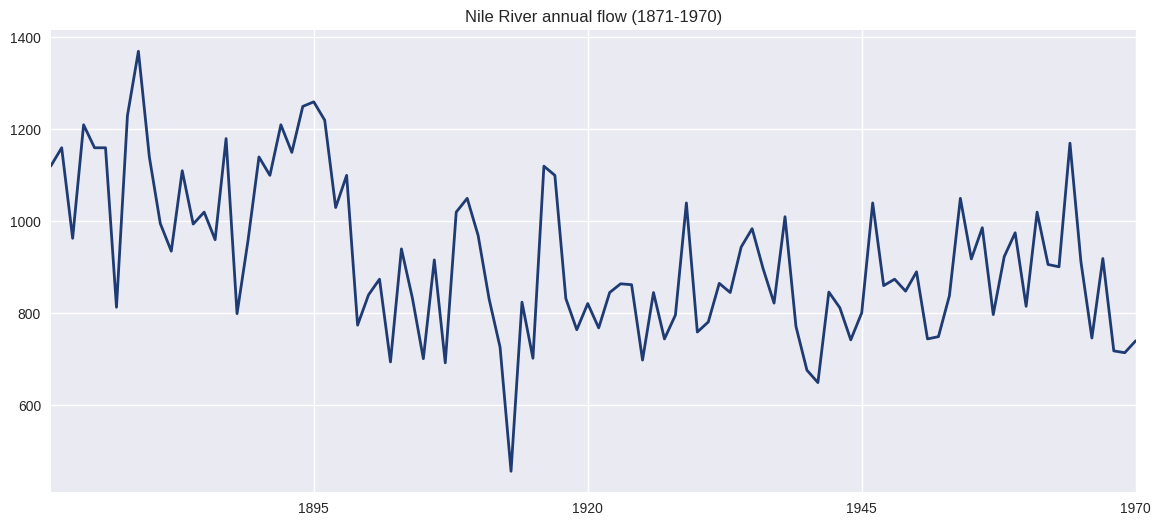

In [9]:
ax = nile_y.plot(color=CFG.c_observed, lw=2, title="Nile River annual flow (1871-1970)")
ax.set_xlabel("")
plt.show()

A plot of the raw data always comes before any modeling. We use pandas' built-in
`Series.plot()` (which delegates to matplotlib) rather than building the figure by hand, passing
our observed-data color and a thick line. Two features jump out. First, there is no obvious
trend or seasonality &mdash; the series wanders, consistent with a noisy random walk. Second,
there is a visible **downward shift in level around 1899**, which historically coincides with the
construction of the first Aswan dam. This structural break is exactly the kind of slow change in
an underlying "level" that a state space model is built to recover from noisy measurements.

In [10]:
print_adf_result(nile_y, name="Nile volume")

ADF test on Nile volume
  test statistic : -4.049
  p-value        : 0.0012
  critical (5%)  : -2.892
  verdict        : stationary


Running our ADF helper on the Nile series gives a small p-value, so the test **rejects** the
unit-root null and labels the series stationary around a constant mean. Yet the plot clearly
shows a *level shift* near 1899 &mdash; the eye and the test disagree, because a single
mean-reversion test can be insensitive to a one-off regime change. This tension is exactly the
opening for state space modeling. Rather than commit to one global mean (which ignores the break)
or difference the data away (which obscures the level entirely), the **local level model** we
build next lets the level *itself* evolve as a random walk, so it can absorb slow drift and
structural breaks while staying parsimonious. The framework treats the changing level as something
to estimate, not a nuisance to remove.

In [11]:
class DKStateSpaceModel:
    '''Minimal Durbin-Koopman Kalman filter for a univariate linear Gaussian model.

        alpha_{t+1} = T alpha_t + R eta_t,   eta_t ~ N(0, Q)
        y_t         = Z alpha_t + eps_t,     eps_t ~ N(0, H)
    '''
    def __init__(self, y, T, Z, R, Q, H, a1, P1):
        self.y = np.asarray(y, dtype=float)
        self.T = np.atleast_2d(np.asarray(T, dtype=float))
        self.Z = np.atleast_2d(np.asarray(Z, dtype=float))
        self.R = np.atleast_2d(np.asarray(R, dtype=float))
        self.Q = np.atleast_2d(np.asarray(Q, dtype=float))
        self.H = np.atleast_2d(np.asarray(H, dtype=float))
        self.a1 = np.atleast_1d(np.asarray(a1, dtype=float))
        self.P1 = np.atleast_2d(np.asarray(P1, dtype=float))
        self.n = len(self.y)
        self.m = self.T.shape[0]

    def filter(self):
        a = np.zeros((self.n + 1, self.m))         # predicted state means
        P = np.zeros((self.n + 1, self.m, self.m)) # predicted state covariances
        a[0], P[0] = self.a1, self.P1
        log_likelihood = 0.0

        for t in range(self.n):
            # 1. Innovation: how wrong was the one-step-ahead prediction?
            v_t = self.y[t] - (self.Z @ a[t]).item()
            # 2. Innovation variance: F = Z P Z' + H
            F_t = (self.Z @ P[t] @ self.Z.T).item() + self.H.item()
            # 3. Kalman gain for updating the current state
            K_t = (P[t] @ self.Z.T) / F_t
            a_upd = a[t] + K_t.flatten() * v_t
            P_upd = P[t] - np.outer(K_t.flatten(), (self.Z @ P[t]).flatten())
            # 4. Transition to t+1:  a_{t+1} = T a_upd ,  P_{t+1} = T P_upd T' + R Q R'
            a[t + 1] = self.T @ a_upd
            P[t + 1] = self.T @ P_upd @ self.T.T + self.R @ self.Q @ self.R.T
            # 5. Accumulate the log-likelihood from this step's prediction error
            log_likelihood += -0.5 * (np.log(2 * np.pi) + np.log(F_t) + v_t ** 2 / F_t)

        return a, P, log_likelihood

This class is the **engine, demystified**. It translates the Durbin-Koopman recursions directly
into NumPy. The constructor stores the five system matrices that fully define a linear Gaussian
state space model &mdash; `T` (transition: how the hidden state evolves), `Z` (design: how the
state maps to observations), `R` (selection: how shocks enter the state), `Q` (state-noise
covariance), and `H` (observation-noise covariance) &mdash; plus the initial state mean `a1` and
covariance `P1`. Wrapping each in `np.atleast_2d` guarantees the matrix algebra works even when
you pass a scalar like `1`.

The `filter` method is the loop that does the work, one observation at a time. For each step `t`
it computes five quantities. **(1)** The *innovation* `v_t` is the one-step-ahead forecast error
&mdash; the gap between the actual observation and what the current state predicted. **(2)** Its
variance `F_t` combines the propagated state uncertainty with the measurement noise. **(3)** The
*Kalman gain* `K_t` decides how much to trust this new data point: when measurement noise `H` is
large, the gain shrinks and the filter leans on the model; when state uncertainty `P` is large,
the gain grows and the filter chases the data. The state mean and covariance are then *updated*
with the new information, and **(4)** propagated forward to the next time step via `T` and the
process noise `R Q R'`. **(5)** Crucially, each step contributes a term to the
**log-likelihood** &mdash; because the innovations are, by construction, serially independent and
Gaussian, summing these terms gives the exact likelihood of the whole series. This is the
*prediction-error decomposition*, and it is what lets us estimate unknown parameters by maximum
likelihood. One subtlety worth flagging: we use `.item()` to pull a Python scalar out of a 1x1
matrix product, because modern NumPy refuses to silently cast a `(1,1)` array to a float.

In [12]:
# Controlled demo: simulate a random walk observed with noise, then filter it
#   mu_{t+1} = mu_t + eta_t      (the hidden level, a random walk)
#   y_t      = mu_t + eps_t      (noisy observation of the level)
N_SIM = 100
true_level = np.random.normal(0, 1, N_SIM).cumsum()
y_sim = true_level + np.random.normal(0, 1, N_SIM)

ssm = DKStateSpaceModel(y_sim, T=1, Z=1, R=1, Q=0.5, H=1.0, a1=0.0, P1=10.0)
states, covs, ll = ssm.filter()

print(f"Total log-likelihood : {ll:.2f}")
print(f"Final filtered level : {states[-2, 0]:.3f}")
print(f"Final true level     : {true_level[-1]:.3f}")

Total log-likelihood : -186.29
Final filtered level : -10.176
Final true level     : -10.385


We test the engine on **controlled data** before trusting it on anything real &mdash; a habit
worth keeping. We simulate the simplest interesting state space process: a hidden level that
follows a random walk (`true_level`, the cumulative sum of Gaussian shocks) which we only get to
see through noisy observations `y_sim`. Because we generated the data, we know the ground truth.

We instantiate `DKStateSpaceModel` with the matrices of a **local level model**: `T=1` (the level
carries forward unchanged in expectation), `Z=1` (we observe the level directly), `R=1`,
`Q=0.5` (the level wanders moderately), and `H=1.0` (observation noise). The diffuse-ish initial
variance `P1=10` says we are quite unsure of the starting level. Calling `.filter()` returns the
filtered state path, its covariances, and the accumulated log-likelihood. Comparing the final
filtered level to the final true level shows the filter has tracked the hidden signal closely
despite the noise &mdash; the recursion really does recover the latent state.

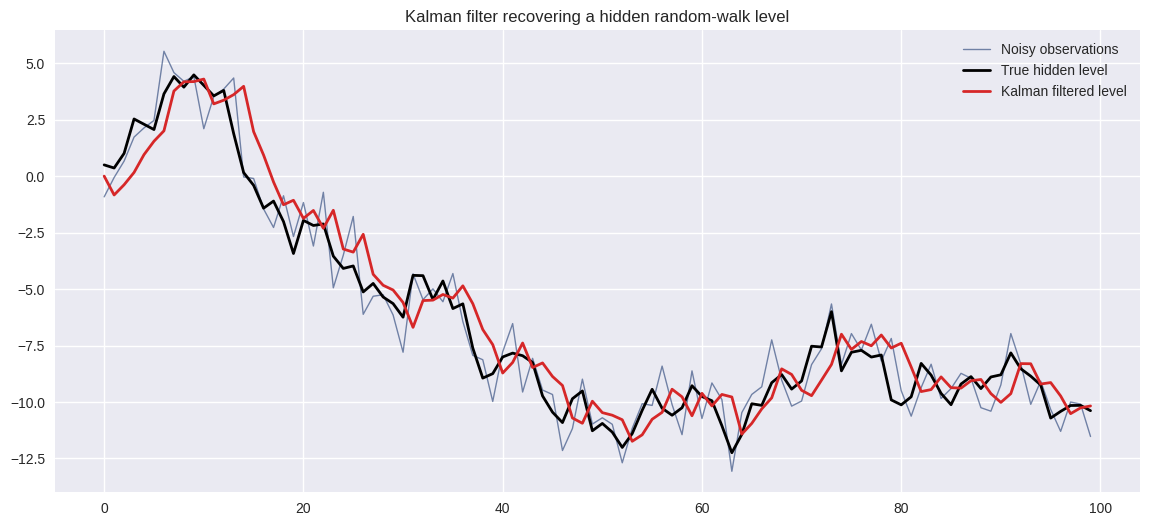

In [13]:
fig, ax = plt.subplots()
ax.plot(y_sim, color=CFG.c_observed, lw=1, alpha=0.6, label="Noisy observations")
ax.plot(true_level, color="black", lw=2, label="True hidden level")
ax.plot(states[:-1, 0], color=CFG.c_fitted, lw=2, label="Kalman filtered level")
ax.set_title("Kalman filter recovering a hidden random-walk level")
ax.legend()
plt.show()

The plot makes the filter's job visible. The faint blue line is the noisy data we feed in; the
black line is the true hidden level we are trying to recover (normally invisible); and the red
line is the filter's estimate. The red estimate **smooths through the observation noise and
hugs the true level** &mdash; without ever being told what the true level is. This is the entire
promise of state space modeling in one picture: separate signal from noise by positing a dynamic
model for the signal. Everything that follows is this same idea with richer state vectors.

# Structural models: the component ladder

Now we climb the ladder using `statsmodels`' high-level `UnobservedComponents` class, which lets
us assemble structural models from named building blocks. Each rung adds **exactly one new
component**:

| Rung | Model | New ingredient |
| --- | --- | --- |
| 1 | Local Level | a stochastic level (random walk) |
| 2 | Local Linear Trend | a stochastic slope (trend) |
| 3 | Basic Structural Model | a stochastic seasonal pattern |

We use the same per-model template throughout &mdash; fit, inspect the summary, forecast,
evaluate, plot &mdash; so you can compare methods rather than re-read boilerplate.

## Local Level Model

The local level model is the simplest non-trivial state space model and exactly the process we
simulated above:

$$y_t = \mu_t + \varepsilon_t, \qquad \mu_{t+1} = \mu_t + \eta_t$$

The level $\mu_t$ is a random walk; we observe it with noise. We fit it to the Nile series, whose
1899 structural break makes the smoothed level especially illuminating.

In [14]:
ll_model = sm.tsa.UnobservedComponents(nile_y, level="local level")
ll_res = ll_model.fit(disp=False)
print(ll_res.summary())

                        Unobserved Components Results                         
Dep. Variable:                 volume   No. Observations:                  100
Model:                    local level   Log Likelihood                -632.538
Date:                Sun, 14 Jun 2026   AIC                           1269.076
Time:                        04:50:13   BIC                           1274.266
Sample:                    01-01-1871   HQIC                          1271.176
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.508e+04   2586.506      5.829      0.000       1e+04    2.01e+04
sigma2.level      1478.8120    851.329      1.737      0.082    -189.762    3147.386
Ljung-Box (L1) (Q):         

We instantiate `UnobservedComponents` with `level="local level"`, which tells `statsmodels` to
build precisely the one-state random-walk-plus-noise model above and wire up its system matrices
internally. Calling `.fit(disp=False)` runs maximum likelihood estimation &mdash; under the hood
this is the Kalman filter we just wrote (in optimized Cython) evaluating the likelihood while an
optimizer searches for the two unknown variances; `disp=False` just hides the optimizer's
iteration log.

The summary reports those two estimated variances. **`sigma2.irregular`** is the observation
noise $\sigma^2_\varepsilon$ (the measurement error `H`), and **`sigma2.level`** is the state
noise $\sigma^2_\eta$ (how fast the true level wanders, `Q`). Their *ratio* is the key quantity:
here the irregular variance is roughly ten times the level variance, telling us the annual
measurements are quite noisy while the underlying level changes only slowly. That is the
**signal-to-noise** story, and it is what justifies smoothing aggressively to recover the latent
level.

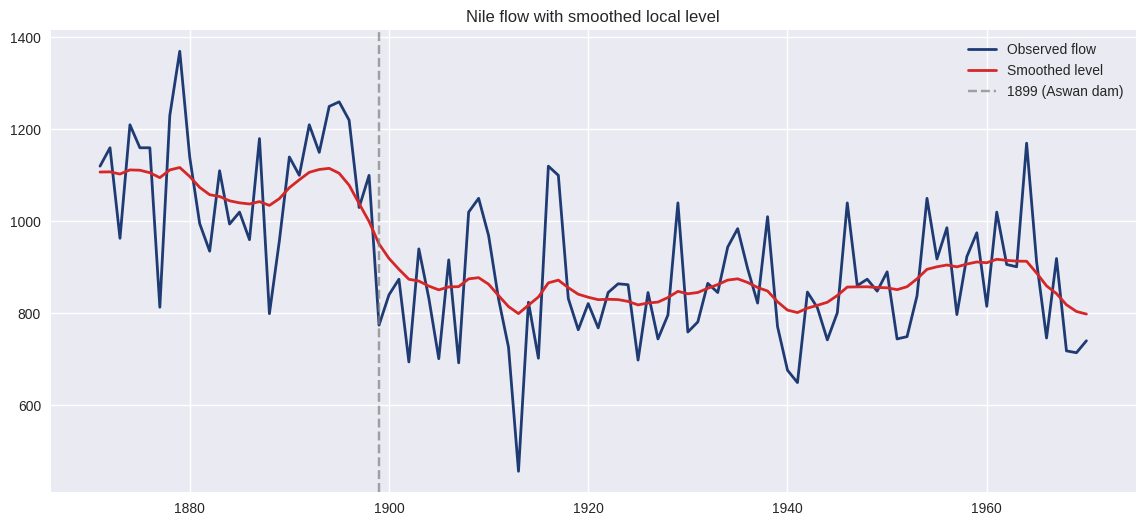

In [15]:
smoothed_level = pd.Series(ll_res.level["smoothed"], index=nile_y.index)

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, color=CFG.c_observed, lw=2, label="Observed flow")
ax.plot(smoothed_level.index, smoothed_level.values, color=CFG.c_fitted, lw=2, label="Smoothed level")
ax.axvline(pd.Timestamp("1899"), color="grey", ls="--", alpha=0.7, label="1899 (Aswan dam)")
ax.set_title("Nile flow with smoothed local level")
ax.legend()
plt.show()

Here we extract the **smoothed** level &mdash; the estimate of $\mu_t$ that uses the *entire*
sample, not just the past &mdash; via `ll_res.level["smoothed"]`, wrapping the returned array
back into a `Series` so it carries the date index. Plotting it over the raw data shows the
smoother doing exactly what the controlled demo promised: it strips out the year-to-year
measurement noise and exposes a clean underlying signal. The recovered level **steps down sharply
around 1899** (marked), recovering the structural break that the dam introduced. A plain ARIMA
forecast would average over this regime change and obscure it; the state space smoother makes it
a visible, interpretable feature.

## Local Linear Trend (adds trend)

The next rung adds a **stochastic slope** $\nu_t$, so the level can drift with momentum rather
than purely at random:

$$y_t = \mu_t + \varepsilon_t,\quad \mu_{t+1} = \mu_t + \nu_t + \xi_t,\quad \nu_{t+1} = \nu_t + \zeta_t$$

To exercise trend (and soon seasonality) we switch to the classic **airline passengers** series,
which has a strong upward trend and a yearly cycle. Its seasonal swings *grow* with the level, so
we model the **log** of the series &mdash; a standard transform that turns multiplicative
seasonality into additive seasonality, which is what these additive structural models assume.

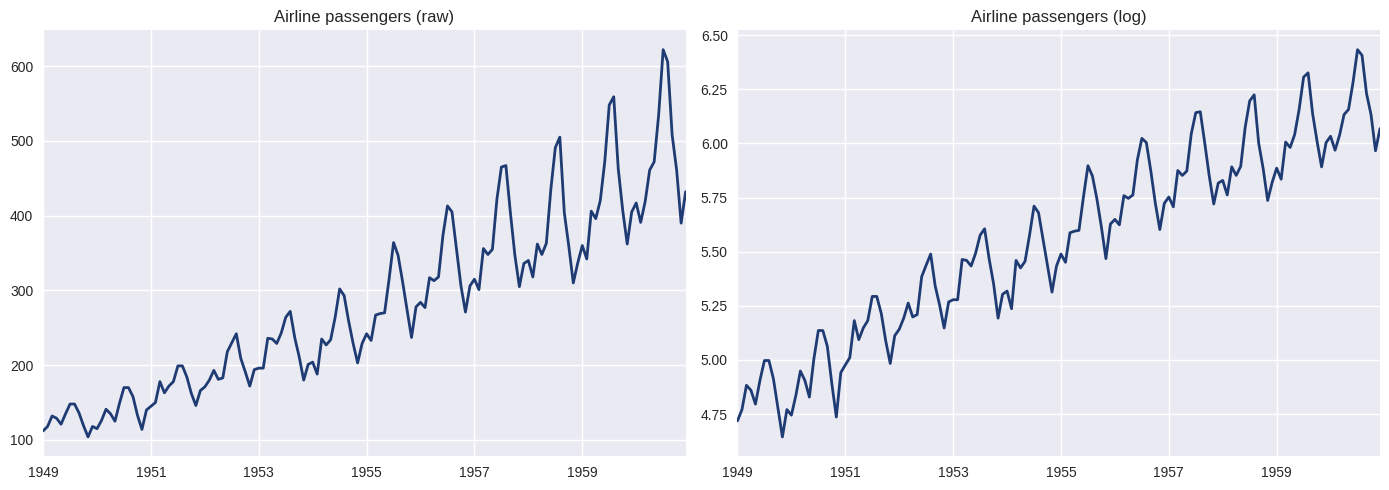

1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
Freq: MS, Name: passengers, dtype: float64

In [16]:
# Airline passengers, monthly, 1949-1960 (via Rdatasets)
air = sm.datasets.get_rdataset("AirPassengers", "datasets").data
air_y = pd.Series(air["value"].to_numpy(dtype=float),
                  index=pd.date_range("1949-01-01", periods=len(air), freq="MS"),
                  name="passengers")
log_y = np.log(air_y)

fig, axes = plt.subplots(1, 2, figsize=(CFG.img_dim1, CFG.img_dim2 // 2 + 2))
air_y.plot(ax=axes[0], color=CFG.c_observed, lw=2, title="Airline passengers (raw)")
log_y.plot(ax=axes[1], color=CFG.c_observed, lw=2, title="Airline passengers (log)")
for a in axes:
    a.set_xlabel("")
plt.tight_layout()
plt.show()
air_y.head(3)

We load the monthly airline passenger counts and attach a proper monthly `DatetimeIndex`
(`freq="MS"` = month-start). Plotting the raw series (left) shows the trademark feature: an upward
trend with seasonal oscillations whose **amplitude grows over time** &mdash; multiplicative
seasonality. The log-transformed series (right) has oscillations of roughly *constant* amplitude;
the log has converted the multiplicative pattern into an additive one. From here on we model
`log_y` and exponentiate predictions back to passenger counts for interpretation. The trailing
`air_y.head(3)` confirms the values and index. This "look first, transform if needed" step is the
groundwork for every model below.

In [17]:
log_train, log_valid = train_valid_split(log_y)

llt_res = sm.tsa.UnobservedComponents(log_train, level="local linear trend").fit(disp=False)

fc = llt_res.get_forecast(CFG.HORIZON)
llt_pred = np.exp(fc.predicted_mean)
valid_orig = np.exp(log_valid)
print("Local Linear Trend (no seasonality):", forecast_metrics(valid_orig, llt_pred))

Local Linear Trend (no seasonality): {'MAE': 76.41, 'RMSE': 100.68, 'MAPE': 15.24}


We split the log series chronologically with our helper, then fit `UnobservedComponents` with
`level="local linear trend"` &mdash; the same class as before, but now requesting the two-state
level-plus-slope model. `get_forecast(CFG.HORIZON)` produces a forecast object for the 24-month
holdout; `.predicted_mean` is the point forecast on the log scale, which we exponentiate with
`np.exp` to return to passenger counts. We score it against the (also back-transformed) actuals
using `forecast_metrics`. The errors will be sizable: this model captures the *trend* but has no
notion of the strong yearly seasonality still plainly visible in the data &mdash; which is
exactly the gap the next rung fills.

## Basic Structural Model (adds seasonality)

The final structural rung adds a **stochastic seasonal component** $s_t$ that sums to roughly
zero over each year and is allowed to evolve slowly. Combined with level and trend, this is the
**Basic Structural Model (BSM)** &mdash; the structural counterpart of an airline-model SARIMA.

In [18]:
bsm_res = sm.tsa.UnobservedComponents(
    log_train,
    level="local linear trend",
    seasonal=CFG.SEASONAL_PERIOD,   # 12 monthly seasonal factors
).fit(disp=False)
print(bsm_res.summary())

                            Unobserved Components Results                            
Dep. Variable:                    passengers   No. Observations:                  120
Model:                    local linear trend   Log Likelihood                 190.458
                   + stochastic seasonal(12)   AIC                           -372.917
Date:                       Sun, 14 Jun 2026   BIC                           -362.226
Time:                               04:50:14   HQIC                          -368.583
Sample:                           01-01-1949                                         
                                - 12-01-1958                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     0.0001      0.000      1.036      0

We add a single keyword, `seasonal=CFG.SEASONAL_PERIOD` (12), and `UnobservedComponents` expands
the state vector to carry eleven seasonal lags alongside the level and slope. That one ingredient
is the only change from the previous rung. The summary now lists a third variance,
**`sigma2.seasonal`**, controlling how much the seasonal pattern is allowed to drift from year to
year &mdash; a small value means a near-fixed seasonal shape, a larger value lets it evolve. The
log-likelihood and AIC also improve substantially over the trend-only model, the first
quantitative sign that seasonality belongs in the model.

Basic Structural Model: {'MAE': 27.71, 'RMSE': 32.58, 'MAPE': 5.77}


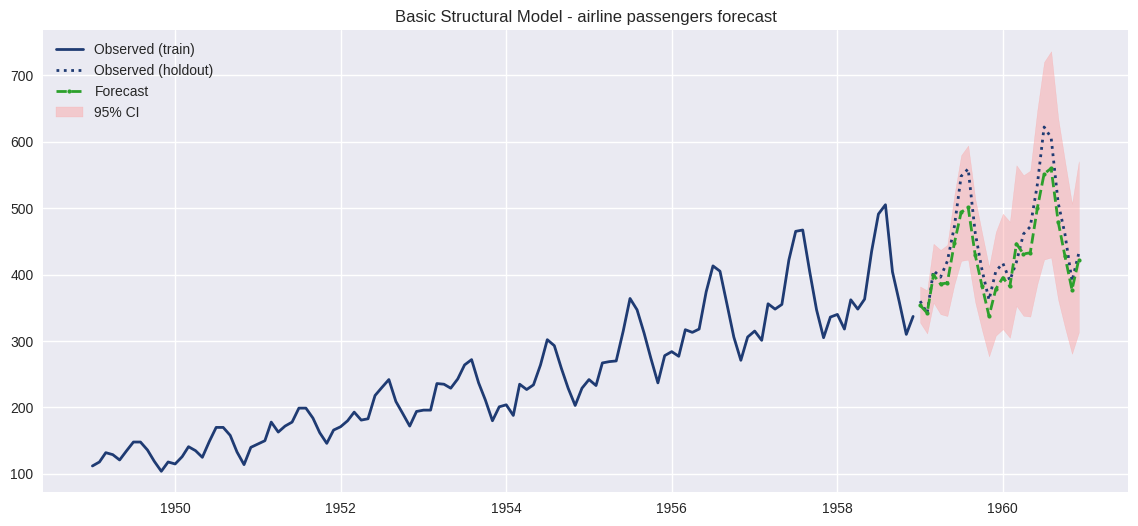

In [19]:
fc = bsm_res.get_forecast(CFG.HORIZON)
ci = fc.conf_int()
bsm_pred  = np.exp(fc.predicted_mean)
bsm_lower = np.exp(ci.iloc[:, 0])
bsm_upper = np.exp(ci.iloc[:, 1])

print("Basic Structural Model:", forecast_metrics(valid_orig, bsm_pred))

plot_forecast(np.exp(log_train), valid_orig, bsm_pred, bsm_lower, bsm_upper,
              title="Basic Structural Model - airline passengers forecast")
plt.show()

This is the full **predict-and-evaluate** template that the remaining models will reuse verbatim.
`get_forecast` gives both the mean and, via `.conf_int()`, the 95% prediction-interval bounds;
we exponentiate all three to passenger counts. The metrics drop sharply now that seasonality is
modeled. The `plot_forecast` overlay tells the visual story: the green dashed forecast reproduces
the seasonal peaks and troughs and lands close to the dotted holdout actuals, with the coral band
showing honest, widening uncertainty as we predict further ahead. Note how cheaply we got here
&mdash; three keyword arguments to one class took us from random walk to a competitive seasonal
forecaster, because each component slots into the same state space scaffold.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:1738: RuntimeWarning: invalid value encountered in sqrt
  std_errors = np.sqrt(component_bunch['%s_cov' % which])


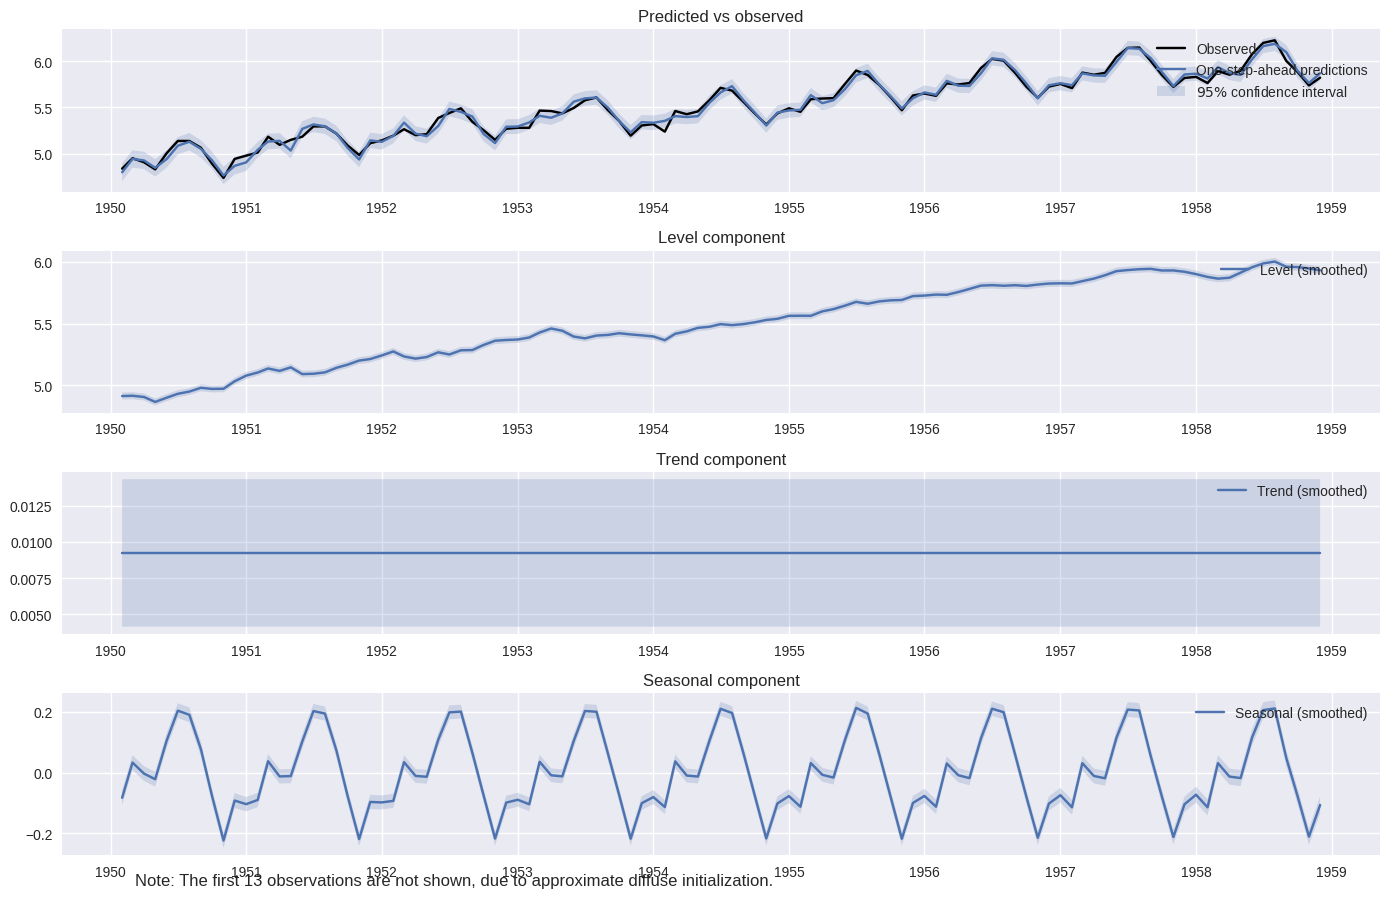

In [20]:
fig = bsm_res.plot_components(figsize=(CFG.img_dim1, CFG.img_dim2 + 3))
plt.tight_layout()
plt.show()

`plot_components` decomposes the fitted model into its estimated latent pieces &mdash; the
smoothed **level**, the **trend/slope**, and the **seasonal** factor &mdash; each shown against
the data it explains. This is the interpretability payoff of structural state space models: rather
than a single opaque forecast, we get a labeled breakdown of *where* the series' behavior comes
from. The level traces the long-run growth, the seasonal panel shows the repeating yearly shape,
and reading them together explains the forecast. "Good" here looks like a smooth level, a stable
seasonal pattern, and a residual component with no obvious leftover structure.

# Unification: familiar models are state space models

The structural ladder built models *from* state space parts. The deeper claim of the
Durbin-Koopman framework is that the methods you already know &mdash; **ARIMA** and **exponential
smoothing** &mdash; are *not separate techniques* but particular state space models in disguise.
`statsmodels` fits both through the very same Kalman-filter likelihood machinery, which is why we
can drop them straight into our existing evaluation template.

## ARIMA as a State Space Model (SARIMAX)

Every ARIMA model can be written in state space form: a state vector that "remembers" enough past
values, a transition matrix carrying the AR coefficients, and a selection vector carrying the MA
coefficients. Non-stationarity (the integration / differencing) is handled by **diffuse
initialization** of the relevant states rather than by differencing the data away. `statsmodels`'
`SARIMAX` is exactly this representation, so fitting an ARIMA here *is* fitting a state space
model.

In [21]:
# The classic "airline model": ARIMA(1,1,1)(0,1,1)_12 on the log series
sarimax_res = sm.tsa.SARIMAX(
    log_train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, CFG.SEASONAL_PERIOD),
).fit(disp=False)
print(sarimax_res.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2243      0.257      0.873      0.383      -0.279       0.728
ma.L1         -0.5542      0.226     -2.450      0.014      -0.998      -0.111
ma.S.L12      -0.5463      0.116     -4.730      0.000      -0.773      -0.320
sigma2         0.0014      0.000      7.294      0.000       0.001       0.002


We fit a `SARIMAX` with `order=(1, 1, 1)` (one AR term, one degree of differencing, one MA term)
and `seasonal_order=(0, 1, 1, 12)` (seasonal differencing plus a seasonal MA term at lag 12)
&mdash; the textbook "airline model". The two differencing operations are what make the series
stationary *inside* the model; in state space terms they correspond to diffusely-initialized
states. We print just `summary().tables[1]`, the coefficient table, which lists the estimated AR
(`ar.L1`), MA (`ma.L1`), and seasonal MA (`ma.S.L12`) parameters with their standard errors and
p-values. Reading those, a coefficient whose p-value is below 0.05 is statistically distinguishable
from zero &mdash; evidence that term is pulling its weight.

SARIMAX: {'MAE': 36.25, 'RMSE': 39.96, 'MAPE': 7.82}


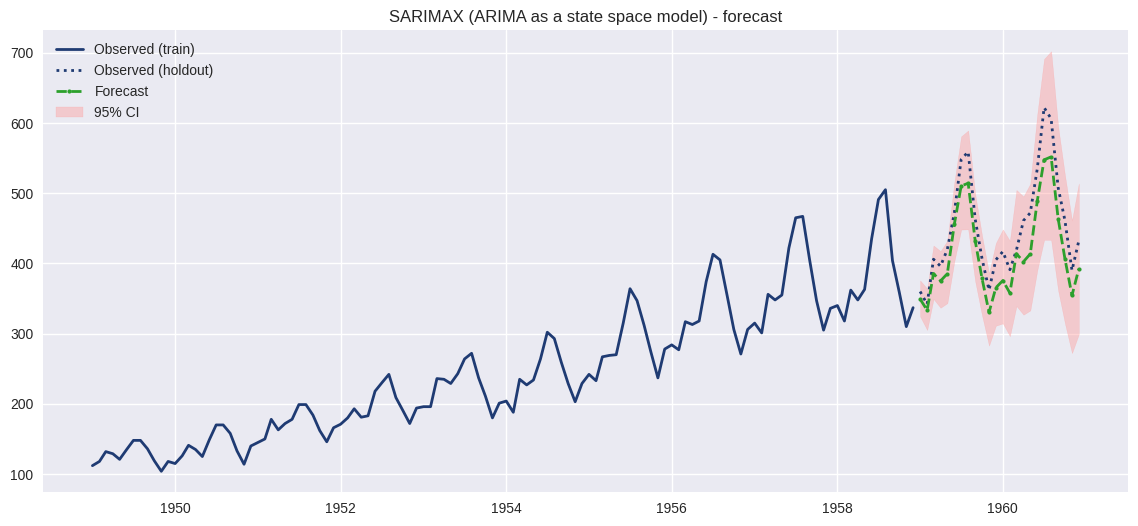

In [22]:
fc = sarimax_res.get_forecast(CFG.HORIZON)
ci = fc.conf_int()
sarimax_pred  = np.exp(fc.predicted_mean)
sarimax_lower = np.exp(ci.iloc[:, 0])
sarimax_upper = np.exp(ci.iloc[:, 1])

print("SARIMAX:", forecast_metrics(valid_orig, sarimax_pred))

plot_forecast(np.exp(log_train), valid_orig, sarimax_pred, sarimax_lower, sarimax_upper,
              title="SARIMAX (ARIMA as a state space model) - forecast")
plt.show()

The forecast-and-evaluate block is **identical** to the one we used for the Basic Structural
Model &mdash; same `get_forecast`, same exponentiation, same metrics, same `plot_forecast`. That
reuse is deliberate: because SARIMAX is just another state space model, it slots into the exact
same workflow, and the only thing worth comparing is the numbers, not the code. The forecast again
tracks the seasonal structure closely. The point is conceptual: an ARIMA model and a structural
model, which look unrelated in textbooks, are here two configurations of one estimation engine.

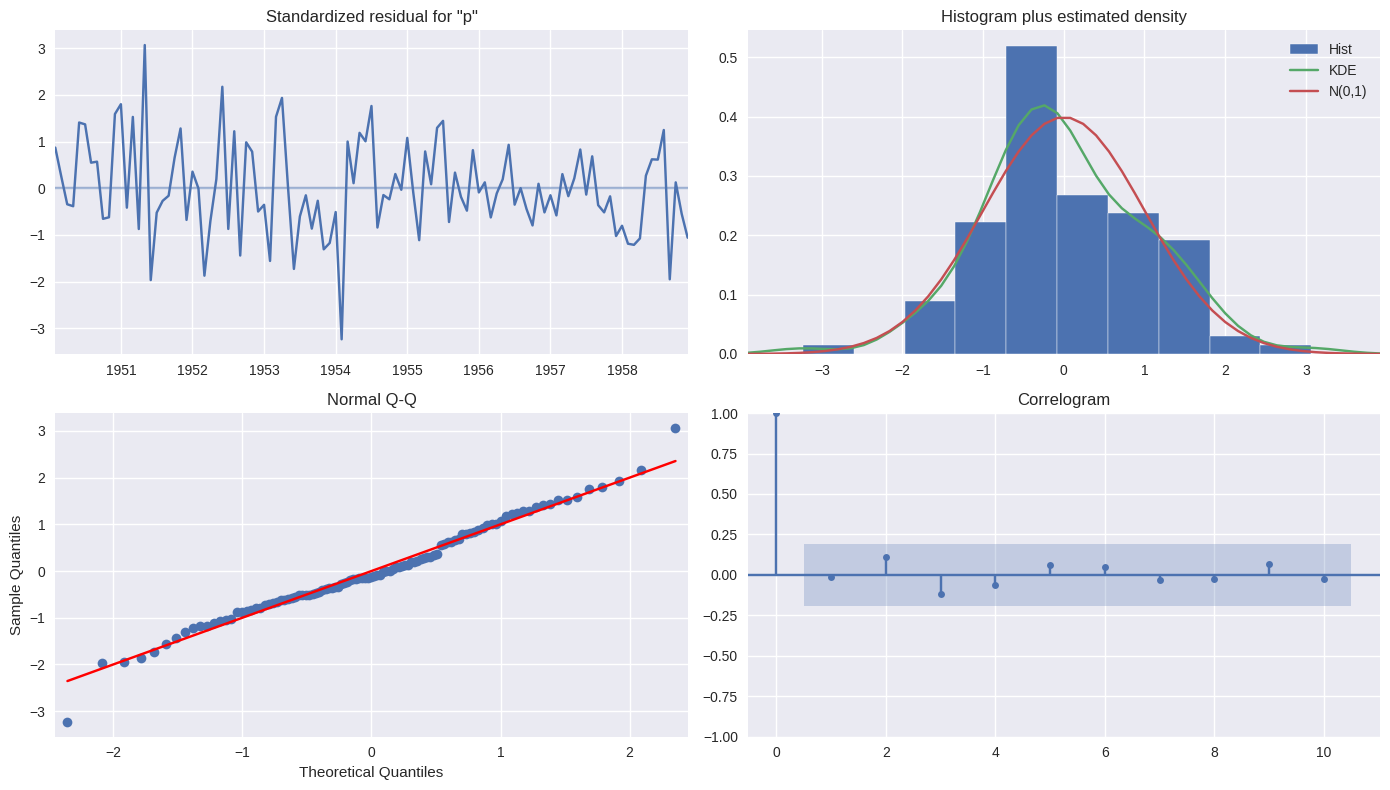

In [23]:
sarimax_res.plot_diagnostics(figsize=(CFG.img_dim1, CFG.img_dim2 + 2))
plt.tight_layout()
plt.show()

`plot_diagnostics` checks the model's **residuals** (the standardized innovations from the Kalman
filter). A well-specified model leaves residuals that are essentially white noise, and the four
panels test exactly that: the top-left standardized-residual plot should look patternless; the
histogram and the Q-Q plot should both track the reference normal curve, indicating Gaussian
errors; and the **correlogram** (bottom-right) should show no significant spikes beyond lag zero,
meaning no leftover autocorrelation for the model to exploit. Spikes in the correlogram would be a
red flag that structure remains unmodeled. This is the standard "is my model adequate?" check, and
it applies uniformly to every state space model.

## Exponential Smoothing as a State Space Model (ETS / SSOE)

Exponential smoothing began in the 1950s as intuitive update formulas with no probability model.
It was later shown to be a state space model of a special kind: a **Single Source of Error
(SSOE)**, or *innovations*, model, where the *same* shock $\varepsilon_t$ drives both the
observation and the update of the latent state. For Simple Exponential Smoothing this collapses to
the elegant relations $T = 1,\ Z = 1,\ R = \alpha$ &mdash; the selection matrix *is* the smoothing
parameter. Casting ETS this way puts it on the same maximum-likelihood footing as ARIMA, enabling
AIC-based model selection and proper prediction intervals.

In [24]:
ets_res = ETSModel(
    log_train,
    error="add", trend="add", seasonal="add",
    seasonal_periods=CFG.SEASONAL_PERIOD,
).fit(disp=False)
print(ets_res.summary().tables[1])

                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.9999      0.086     11.589      0.000       0.831       1.169
smoothing_trend      9.999e-05        nan        nan        nan         nan         nan
smoothing_seasonal    7.69e-05        nan        nan        nan         nan         nan
initial_level           4.7092    368.130      0.013      0.990    -716.813     726.232
initial_trend           0.0093      0.003      2.860      0.004       0.003       0.016
initial_seasonal.0     -0.0108    368.130  -2.94e-05      1.000    -721.533     721.511
initial_seasonal.1     -0.1287    368.130     -0.000      1.000    -721.651     721.393
initial_seasonal.2      0.0126    368.130   3.41e-05      1.000    -721.510     721.535
initial_seasonal.3      0.1530    368.130      0.000      1.000    -721.369     721.675
initial_seasonal.4      0.2873  

We use `ETSModel` &mdash; the **state space** implementation of exponential smoothing &mdash; with
additive error, trend, and seasonal components (the ETS(A,A,A) specification, the direct analogue
of additive Holt-Winters). This is a deliberately different class from the older
`sm.tsa.ExponentialSmoothing`: that one uses the classical recursive formulas and is limited in
its statistical output, whereas `ETSModel` solves the underlying innovations likelihood with the
Kalman machinery, which is what gives it proper prediction intervals, simulation, and AIC/BIC. The
coefficient table reports the estimated **smoothing parameters** &mdash; `smoothing_level`
($\alpha$), `smoothing_trend` ($\beta$), and `smoothing_seasonal` ($\gamma$) &mdash; each between
0 and 1, governing how quickly the level, slope, and seasonal pattern adapt to new data.

In [25]:
ets_pred = np.exp(ets_res.forecast(CFG.HORIZON))
print("ETS (innovations state space):", forecast_metrics(valid_orig, ets_pred))
print(f"AIC  |  BSM: {bsm_res.aic:8.1f}   SARIMAX: {sarimax_res.aic:8.1f}   ETS: {ets_res.aic:8.1f}")

ETS (innovations state space): {'MAE': 31.77, 'RMSE': 36.96, 'MAPE': 6.65}
AIC  |  BSM:   -372.9   SARIMAX:   -387.3   ETS:   -425.0


`ETSModel` exposes a simple `.forecast(h)` that returns the point forecast directly (no separate
prediction-mean attribute), which we exponentiate and score as before. We also print the **AIC**
of the three seasonal models side by side. Because all three are now fitted by maximum likelihood
within the state space framework, their AICs are directly comparable &mdash; a lower value
indicates a better trade-off between fit and complexity. This comparability is precisely the gift
of unification: heuristic exponential smoothing, ARIMA, and structural models can be ranked on a
single principled scale, something impossible when they lived in separate methodological worlds.

# Building and applying custom models

The high-level classes cover common cases, but the real power of the framework is that you can
specify *any* linear Gaussian model by writing down its system matrices. We do that with
`MLEModel`, then exploit a signature strength of the approach &mdash; native handling of missing
data.

## A custom model with MLEModel

To build a model by hand we subclass `MLEModel`, define the fixed matrices in `__init__`, declare
which parameters are free, and map those parameters into the covariance matrices in `update`.
We reimplement the **local linear trend** model from scratch to see the wiring `UnobservedComponents`
hides.

In [26]:
class LocalLinearTrend(MLEModel):
    '''Local linear trend specified directly from system matrices.'''
    start_params = [0.1, 0.1, 0.1]
    param_names = ["sigma2.measurement", "sigma2.level", "sigma2.trend"]

    def __init__(self, endog):
        super().__init__(endog, k_states=2, k_posdef=2,
                         initialization="approximate_diffuse")
        # y_t = [1 0] alpha_t           (we observe the level only)
        self["design"] = np.array([[1.0, 0.0]])
        # level_{t+1} = level_t + trend_t ;  trend_{t+1} = trend_t
        self["transition"] = np.array([[1.0, 1.0],
                                       [0.0, 1.0]])
        # both shocks enter their own state directly
        self["selection"] = np.eye(2)

    def transform_params(self, unconstrained):
        # optimizer works unconstrained; square to guarantee positive variances
        return unconstrained ** 2

    def untransform_params(self, constrained):
        return constrained ** 0.5

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]     # H : measurement variance
        self["state_cov", 0, 0] = params[1]   # Q : level shock variance
        self["state_cov", 1, 1] = params[2]   # Q : trend shock variance


custom_res = LocalLinearTrend(log_train).fit(disp=False)
print(custom_res.params.round(6))

sigma2.measurement    0.000000
sigma2.level          0.011203
sigma2.trend          0.000000
dtype: float64


This class spells out the model `UnobservedComponents` built for us earlier. In `__init__` we call
the parent with `k_states=2` (level and trend) and `k_posdef=2` (two independent shocks), plus
`initialization="approximate_diffuse"` to handle the non-stationary states &mdash; the practical
form of the diffuse initialization the theory calls for. We then set the three fixed matrices: the
**design** `[1 0]` says observations see only the level; the **transition** `[[1,1],[0,1]]`
encodes "next level = level + trend, next trend = trend"; and the **selection** identity routes
each shock to its own state.

The free parameters are the three variances, named in `param_names` with initial guesses in
`start_params`. The `transform_params` / `untransform_params` pair is the **essential gotcha**:
the optimizer searches over the whole real line, but variances must be positive, so we let it work
on an unconstrained value and *square* it before use (and take the square root to convert back).
Omitting this lets the optimizer wander into negative "variances" and return nonsense. Finally,
`update` writes the current parameter values into the observation covariance `H` and the two
diagonal entries of the state covariance `Q`. With that, `MLEModel` supplies the entire
likelihood-and-fitting apparatus for free, and the printed parameters are all sensibly positive.

## Application: missing-data interpolation

A standout advantage of the state space framework is that **missing observations need no
imputation**. When a value is absent the Kalman filter simply skips the update step &mdash; it
predicts forward, lets uncertainty grow, and the backward smoother later fills the gap optimally
using both sides of the data. We demonstrate by deleting a stretch of the Nile series.

In [27]:
GAP_START, GAP_END = 40, 55      # delete observations in this index range

nile_gapped = nile_y.copy().astype(float)
nile_gapped.iloc[GAP_START:GAP_END] = np.nan
print(f"Inserted {nile_gapped.isna().sum()} missing values "
      f"({nile_y.index[GAP_START].year}-{nile_y.index[GAP_END-1].year})")

gap_res = sm.tsa.UnobservedComponents(nile_gapped, level="local level").fit(disp=False)
interp = pd.Series(gap_res.states.smoothed["level"].values, index=nile_y.index)

Inserted 15 missing values (1911-1925)


We copy the Nile series and overwrite a 15-year block (indices 40&ndash;54) with `np.nan` to
simulate a gap in the record. We then fit the **same local level model** as before &mdash; no
special arguments, no pre-filling. `statsmodels` detects the `NaN`s and handles them natively
inside the filter. We pull the smoothed level out of `gap_res.states.smoothed["level"]`, which
carries an estimate for *every* time point, including the missing ones, because the backward
smoother reconstructs them from the surrounding observations and the model dynamics. This is
optimal interpolation, not crude fill.

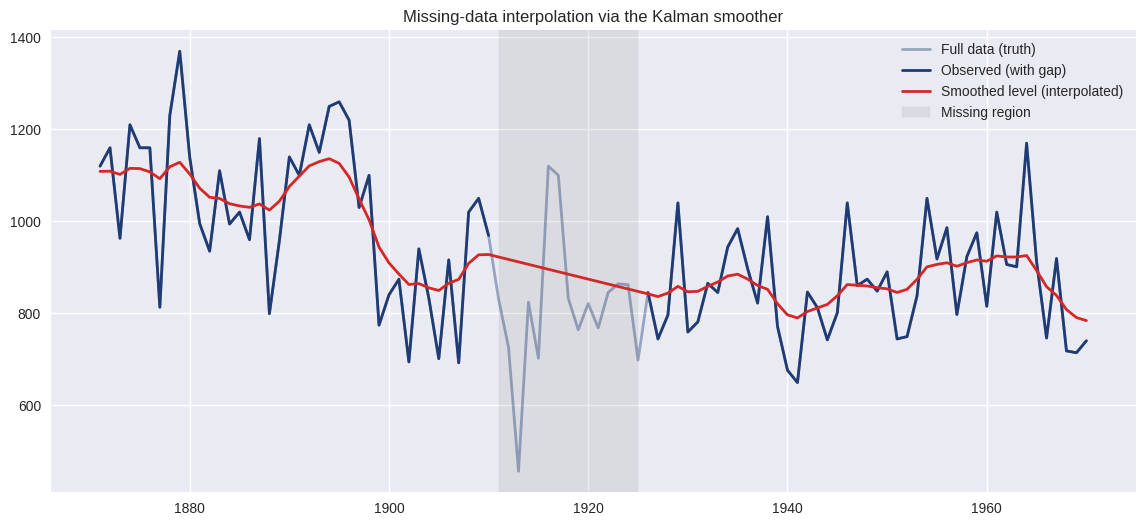

In [28]:
fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, color=CFG.c_observed, lw=2, alpha=0.4, label="Full data (truth)")
ax.plot(nile_gapped.index, nile_gapped.values, color=CFG.c_observed, lw=2, label="Observed (with gap)")
ax.plot(interp.index, interp.values, color=CFG.c_fitted, lw=2, label="Smoothed level (interpolated)")
ax.axvspan(nile_y.index[GAP_START], nile_y.index[GAP_END - 1], color="grey", alpha=0.15, label="Missing region")
ax.set_title("Missing-data interpolation via the Kalman smoother")
ax.legend()
plt.show()

The plot overlays three things: the full original series in faint blue (the truth we hid from the
model), the gapped series the model actually saw, and the red smoothed level. Across the shaded
missing region &mdash; where the model had **no data at all** &mdash; the red estimate bridges the
gap smoothly and stays close to the hidden true values. The filter widens its uncertainty over the
gap and the smoother then back-fills using data from *after* the gap as well as before, producing
a coherent interpolation. Achieving this in a Box-Jenkins ARIMA workflow would require separate
imputation machinery; here it falls out of the framework for free.

# Head-to-head comparison

Finally we line up the seasonal forecasters &mdash; all fitted as state space models &mdash; on
the same airline holdout, scored with the same metric. We use the trend-only **Local Linear
Trend** model as the baseline to quantify how much the seasonal models add.

In [29]:
scores = {
    "LocalLinearTrend": forecast_metrics(valid_orig, llt_pred)["RMSE"],
    "BasicStructural":  forecast_metrics(valid_orig, bsm_pred)["RMSE"],
    "SARIMAX":          forecast_metrics(valid_orig, sarimax_pred)["RMSE"],
    "ETS":              forecast_metrics(valid_orig, ets_pred)["RMSE"],
}
comparison = compare_models(scores, baseline="LocalLinearTrend")
comparison

,model,RMSE,delta_vs_baseline,improved
0,BasicStructural,32.58,-68.10,True
1,ETS,36.96,-63.72,True
2,SARIMAX,39.96,-60.72,True
3,LocalLinearTrend,100.68,0.00,False


We collect each model's holdout RMSE (on the original passenger scale) into a dictionary and feed
it to our `compare_models` helper, with the trend-only model as the baseline. The resulting tidy
table sorts the models best-first and reports, for each, its RMSE, the **delta** versus the
baseline (negative = better), and an `improved` flag. The story is unambiguous: every model that
includes seasonality slashes the error relative to the trend-only baseline, confirming
quantitatively what the component plots suggested &mdash; the yearly cycle is the dominant feature
of this series, and any adequate model must capture it.

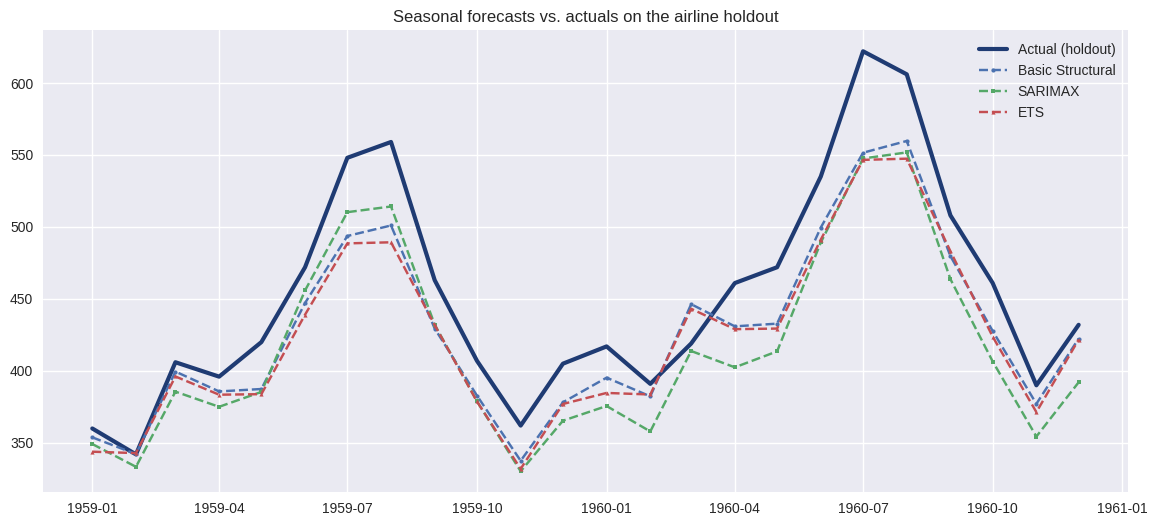

In [30]:
fig, ax = plt.subplots()
ax.plot(valid_orig.index, valid_orig.values, color=CFG.c_observed, lw=3, label="Actual (holdout)")
ax.plot(bsm_pred.index, bsm_pred.values, ls="--", marker="o", ms=3, label="Basic Structural")
ax.plot(sarimax_pred.index, sarimax_pred.values, ls="--", marker="s", ms=3, label="SARIMAX")
ax.plot(ets_pred.index, ets_pred.values, ls="--", marker="^", ms=3, label="ETS")
ax.set_title("Seasonal forecasts vs. actuals on the airline holdout")
ax.legend()
plt.show()

The overlay shows the three seasonal forecasts against the actual holdout values. All three track
the seasonal peaks and the upward trend closely and cluster near the truth, which is the visual
counterpart of their similar RMSEs &mdash; reassuring, since they are ultimately three
parameterizations of the same underlying state space idea. Where they differ is in emphasis: the
structural model offers the cleanest component-level interpretability, SARIMAX the familiar
ARIMA vocabulary, and ETS the gentlest path from classical smoothing. The framework lets you move
between them fluidly and pick the specification that best fits the question at hand.

# Conclusion

We climbed from a hand-written Kalman filter to a head-to-head model contest without ever leaving
a single framework. Three ideas carry the whole notebook:

- **Unification.** ARIMA and exponential smoothing are not rivals to structural models &mdash;
  they are restrictions of the same general linear Gaussian state space form, fitted by the same
  likelihood.
- **Flexibility.** Separating a *state equation* (dynamics) from an *observation equation*
  (measurement) lets us assemble models from interpretable components &mdash; level, trend,
  seasonal &mdash; and handle non-stationarity and missing data without special-casing.
- **Computability.** The Kalman filter and smoother turn all of this into fast recursive matrix
  arithmetic, with the prediction-error decomposition delivering the exact likelihood for maximum
  likelihood estimation.

The practical upshot is the comparison table: once every method is a state space model, you can
fit, score, and rank them on one honest footing, and choose the specification that best matches
your data and your need for interpretability.